In [5]:
import sys
sys.path.insert(0, '/users/framunno/projects/ionosphere_diffusion')

import pandas as pd
from src.data.dataset import IonoSequenceIterableDataset, IonoSequenceDataset

CSV_PATH = '/users/framunno/data/ionosphere/l1_to_map_matched_2020_2025.csv'

# --- Build datasets with exact same params as training_pred.py ---
train_dataset = IonoSequenceIterableDataset(
    csv_path=CSV_PATH,
    split='train',
    sequence_length=22,
    normalization_type='absolute_max',
    use_l1_conditions=True,
    min_center_distance=15,
    cartesian_transform=True,   # skip actual map loading for speed
    output_size=64,
    only_complete_sequences=True,
    seed=42,
    dp_rank=0,
    dp_world_size=1,
)

val_dataset = IonoSequenceIterableDataset(
    csv_path=CSV_PATH,
    split='valid',
    sequence_length=22,
    normalization_type='absolute_max',
    use_l1_conditions=True,
    min_center_distance=30,
    cartesian_transform=True,
    output_size=64,
    only_complete_sequences=True,
    seed=42,
    dp_rank=0,
    dp_world_size=1,
)

print(f"Train sequences: {len(train_dataset.sequences):,}")
print(f"Val   sequences: {len(val_dataset.sequences):,}")
print(f"Train/Val ratio: {len(train_dataset.sequences)/len(val_dataset.sequences):.2f}")

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

# --- Inspect center timestamps for each split ---
train_ts = [train_dataset.all_timestamps[i] for i in train_dataset.sequences]
val_ts   = [val_dataset.all_timestamps[i]   for i in val_dataset.sequences]

train_ts = pd.Series(train_ts)
val_ts   = pd.Series(val_ts)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].hist(train_ts, bins=100, color='steelblue')
axes[0].set_title('Train sequence center timestamps')
axes[0].set_ylabel('Count')

axes[1].hist(val_ts, bins=100, color='coral')
axes[1].set_title('Val sequence center timestamps')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('split_sequences.png', dpi=120)
plt.close()
print("saved split_sequences.png")

# --- Inspect a single batch (no actual map loading needed) ---
import torch

sample = next(iter(train_dataset))                                                                                                                                                 
data_seq, cond_seq, epsilon_seq, label_seq = sample                                                                                                                                
                                                                                                                                                                                    
print(f"maps shape:       {data_seq.shape}")      # (sequence_length, 1, H, W)                                                                                                     
print(f"conditions shape: {cond_seq.shape}")      # (sequence_length, 4)                                                                                                         
print(f"epsilon:          {epsilon_seq}")         # scalar or per-frame                                                                                                            
print(f"activity label:   {label_seq}")           # 0=low, 1=medium, 2=high 


Building L1 conditions cache for train split...
Cached L1 conditions for 1370626 files

COMPUTING EPSILON THRESHOLDS FOR TRAIN SPLIT
Computed from 63402 sequences:
  Mean:   0.4 GW
  Median: 0.2 GW
  Min:    0.0 GW
  Max:    109.5 GW

Activity thresholds:
  Low (0):    epsilon < 0.1 GW
  Medium (1): 0.1 GW ≤ epsilon < 0.4 GW
  High (2):   epsilon ≥ 0.4 GW

Filtered sequences for train: 63402 -> 43781 (69.1% complete)
IonoSequenceIterableDataset [train]: 43781 sequences
  GPU rank: 0/1, Shuffle: True
Building L1 conditions cache for valid split...
Cached L1 conditions for 1370626 files

COMPUTING EPSILON THRESHOLDS FOR VALID SPLIT
Computed from 12649 sequences:
  Mean:   0.4 GW
  Median: 0.1 GW
  Min:    0.0 GW
  Max:    81.7 GW

Activity thresholds:
  Low (0):    epsilon < 0.0 GW
  Medium (1): 0.0 GW ≤ epsilon < 0.4 GW
  High (2):   epsilon ≥ 0.4 GW

Filtered sequences for valid: 12649 -> 9168 (72.5% complete)
IonoSequenceIterableDataset [valid]: 9168 sequences
  GPU rank: 0/1, Shuffle

/tmp/ipykernel_36929/4159019220.py:53: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  im_polar = ax_map.pcolormesh(theta_grid, r_grid, cartesian_to_polar_display(maps[0]),


Saved: /users/framunno/data/ionosphere/sequence_preview.gif


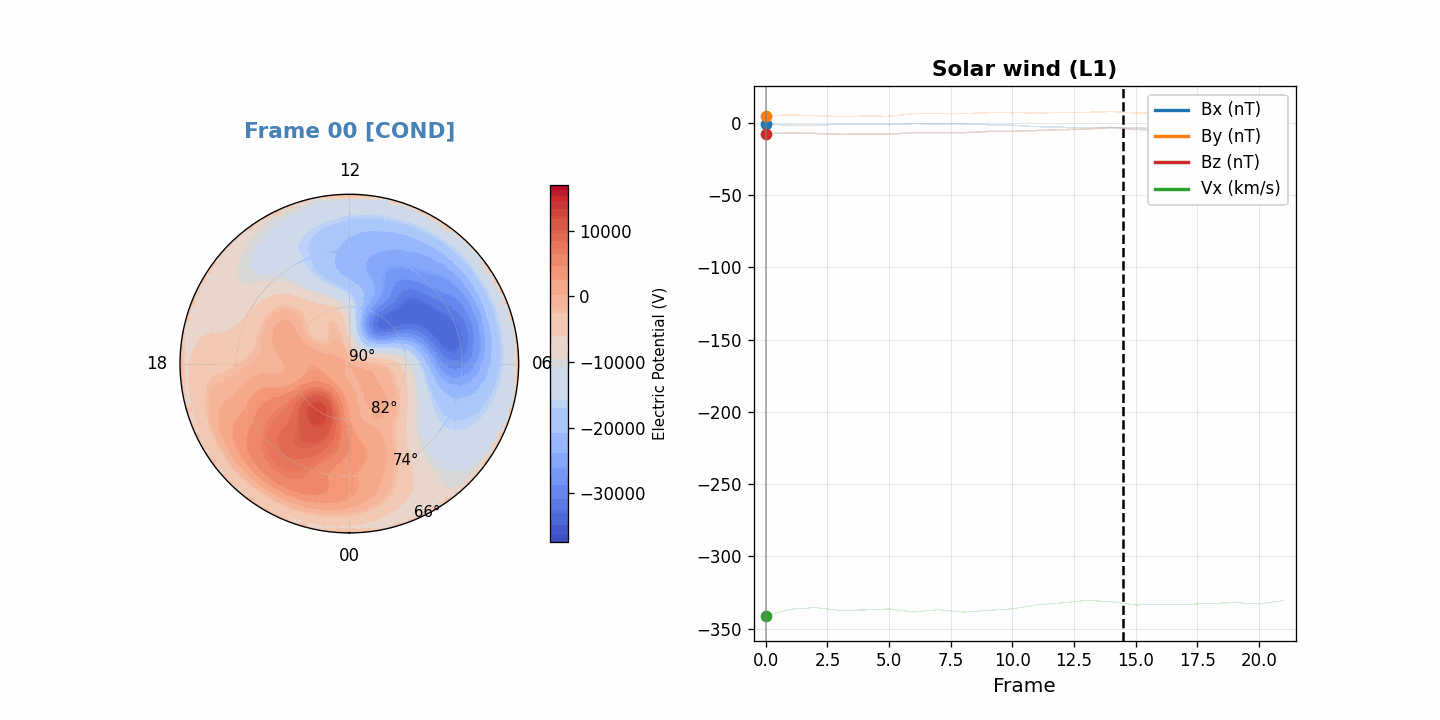

In [6]:
import numpy as np                                                                                                                                                                 
import matplotlib                                                                                                                                                                  
matplotlib.use('Agg')                                                                                                                                                              
import matplotlib.pyplot as plt       
import matplotlib.animation as animation                                                                                                                                           
from scipy.interpolate import griddata                                                                                                                                             
from IPython.display import Image                                                                                                                                                  
                                                                                                                                                                                    
# --- Denormalize ---                                                         
maps_norm  = data_seq.numpy()[:, 0, :, :]   # (30, 64, 64)  in [-1, 1]
conds_norm = cond_seq.numpy()               # (30, 4)       in [-1, 1]       
                                                                                                                                                                                    
# Maps: [-1, 1] → [-80000, 80000] V                                           
maps = (maps_norm + 1) / 2 * (80000 - (-80000)) + (-80000)                                                                                                                         
                                                                                                                                                                                    
# L1 conditions: [-1, 1] → original physical units                                                                                                                                 
# cond order: [bx_gsm, by_gsm, bz_gsm, proton_vx_gsm]                                                                                                                              
cond_min = train_dataset.cond_min  # shape (4,)                                                                                                                                    
cond_max = train_dataset.cond_max  # shape (4,)                                                                                                                                    
conds = (conds_norm + 1) / 2 * (cond_max - cond_min) + cond_min               
                                                                                                                                                                                    
CONDITIONING_LENGTH = 15                                                                                                                                                           
num_frames = maps.shape[0]                                                                                                                                                         
size = 64                                                                                                                                                                          
max_r = 24                                                                                                                                                                         
                                                                            
# Polar display grid                                                                                                                                                               
r_i     = np.linspace(0, max_r, 200)  
theta_i = np.linspace(0, 2 * np.pi, 360)                                     
r_grid, theta_grid = np.meshgrid(r_i, theta_i)                                                                                                                                     
                                                                            
def cartesian_to_polar_display(data_2d):                                                                                                                                           
    x = np.linspace(-max_r, max_r, size)                                                                                                                                           
    y = np.linspace(-max_r, max_r, size)                                     
    x_cart, y_cart = np.meshgrid(x, y)                                                                                                                                             
    points = np.column_stack((x_cart.flatten(), y_cart.flatten()))           
    values = data_2d.flatten()                                                                                                                                                     
    return griddata(points, values,                                                                                                                                                
                    (r_grid * np.cos(theta_grid), r_grid * np.sin(theta_grid)),
                    method='linear', fill_value=0)                                                                                                                                 
                
vmin, vmax = maps.min(), maps.max()                                                                                                                                                
time_axis  = np.arange(num_frames)
                                                                            
# --- Figure ---                                                              
fig = plt.figure(figsize=(12, 6))     
gs  = fig.add_gridspec(1, 2, width_ratios=[1, 1.4], wspace=0.4)
                                                                                                                                                                                    
ax_map   = fig.add_subplot(gs[0, 0], polar=True)                              
ax_solar = fig.add_subplot(gs[0, 1])                                                                                                                                               
                                    
# Polar map                                                                                                                                                                        
im_polar = ax_map.pcolormesh(theta_grid, r_grid, cartesian_to_polar_display(maps[0]),                                                                                              
                            shading='auto', cmap='coolwarm', vmin=vmin, vmax=vmax)                                                                                               
ax_map.set_theta_zero_location('S')                                                                                                                                                
ax_map.set_theta_direction(1)                                                 
ax_map.set_yticks([0, 8, 16, 24])                                            
ax_map.set_yticklabels(['90°', '82°', '74°', '66°'], fontsize=9)                                                                                                                   
ax_map.set_xticks(np.deg2rad([0, 90, 180, 270]))                                                                                                                                   
ax_map.set_xticklabels(['00', '06', '12', '18'], fontsize=10)                                                                                                                      
ax_map.grid(True, alpha=0.3)                                                                                                                                                       
title_txt = ax_map.set_title('Frame 0 [COND]', fontsize=13, fontweight='bold', pad=15)
plt.colorbar(im_polar, ax=ax_map, fraction=0.046, pad=0.08).set_label('Electric Potential (V)', fontsize=9)                                                                        
                                                                                                                                                                                    
# Solar wind — physical units                                                                                                                                                      
colors_sw = ['tab:blue', 'tab:orange', 'tab:red', 'tab:green']                                                                                                                     
labels_sw = ['Bx (nT)', 'By (nT)', 'Bz (nT)', 'Vx (km/s)']                                                                                                                         
for k in range(4):                                                                                                                                                                 
    ax_solar.plot(time_axis, conds[:, k], color=colors_sw[k], alpha=0.2, linewidth=1)                                                                                              
ax_solar.axvline(CONDITIONING_LENGTH - 0.5, color='black', linestyle='--', linewidth=1.5)                                                                                          
ax_solar.set_xlim(-0.5, num_frames - 0.5)                                                                                                                                          
ax_solar.set_xlabel('Frame', fontsize=12)                                                                                                                                          
ax_solar.set_title('Solar wind (L1)', fontsize=13, fontweight='bold')        
ax_solar.grid(True, alpha=0.3)                                                                                                                                                     
                                                                                                                                                                                    
solar_lines = [ax_solar.plot([], [], color=colors_sw[k], linewidth=2, label=labels_sw[k])[0]
                for k in range(4)]                                                                                                                                                  
solar_dots  = [ax_solar.plot([], [], 'o', color=colors_sw[k], markersize=6)[0]
                for k in range(4)]                                                                                                                                                  
ax_solar.legend(fontsize=10, loc='upper right')                                                                                                                                    
vline = ax_solar.axvline(0, color='gray', linewidth=1.2, alpha=0.6)
                                                                                                                                                                                    
def update(frame):                                                                                                                                                                 
    im_polar.set_array(cartesian_to_polar_display(maps[frame]).ravel())
    label = 'COND' if frame < CONDITIONING_LENGTH else 'PRED'                                                                                                                      
    color = 'steelblue' if frame < CONDITIONING_LENGTH else 'firebrick'                                                                                                            
    title_txt.set_text(f'Frame {frame:02d} [{label}]')                        
    title_txt.set_color(color)                                                                                                                                                     
    for k in range(4):                                                       
        solar_lines[k].set_data(time_axis[:frame+1], conds[:frame+1, k])                                                                                                           
        solar_dots[k].set_data([time_axis[frame]], [conds[frame, k]])
    vline.set_xdata([frame, frame])                                                                                                                                                
    return [im_polar, title_txt, vline] + solar_lines + solar_dots                                                                                                                 
                                    
ani = animation.FuncAnimation(fig, update, frames=num_frames, interval=300, blit=True)                                                                                             
out = '/users/framunno/data/ionosphere/sequence_preview.gif'                                                                                                                       
ani.save(out, writer='pillow', fps=4, dpi=120)
plt.close()                                                                                                                                                                        
print(f"Saved: {out}")                                                                                                                                                             
Image(out)   